## Comparison of the derivative using analytical and dual

In [46]:
import numpy as np
import matplotlib.pyplot as plt
from dual_autodiff import Dual 

In [47]:
def f(x):
    """The function f(x) = log(sin(x)) + x^2 * cos(x)"""
    if isinstance(x, Dual):
        return x.sin().log() + (x * x * x.cos())
    return np.log(np.sin(x)) + x**2 * np.cos(x)

In [48]:
def analytical_derivative(x):
    """Analytical derivative of f(x)"""
    return np.cos(x)/np.sin(x) + 2*x*np.cos(x) - x**2*np.sin(x)

In [49]:
def numerical_derivative(f, x, h):
    """Compute numerical derivative using central difference"""
    return (f(x + h) - f(x - h)) / (2 * h)

In [50]:
x_dual=Dual(1.5,1.0)
result_dual=f(x_dual)
derivative_dual=result_dual.dual


In [51]:
# Compute analytical derivative
derivative_analytical = analytical_derivative(1.5)

In [52]:
# Compute numerical derivatives with different step sizes
step_sizes_small = np.logspace(-16, 0, num=50) #small
derivatives_numerical_small = [numerical_derivative(f, 1.5, h) for h in step_sizes_small]

In [53]:
# Calculate absolute errors
errors = np.abs(derivatives_numerical_small - derivative_analytical)
dual_error = abs(derivative_dual - derivative_analytical)

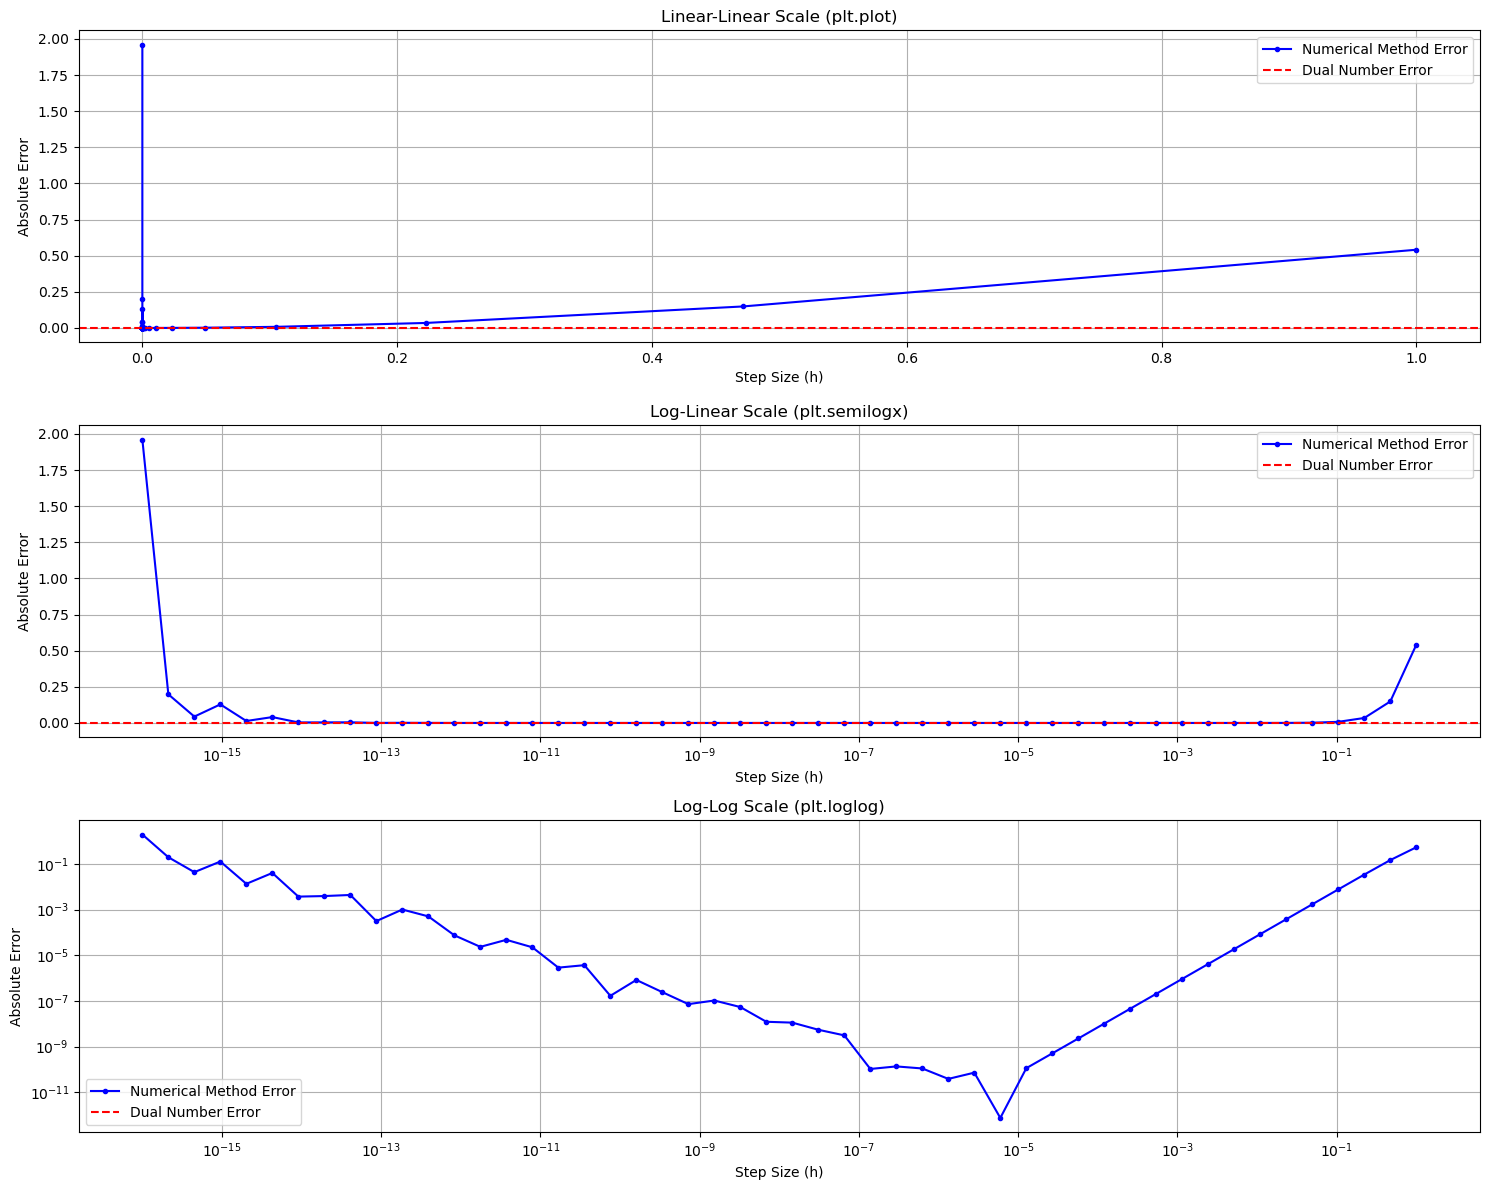

In [54]:
#plt.style.use('seaborn')
fig, (ax1,ax2,ax3) = plt.subplots(3, 1, figsize=(15, 12))

ax1.plot(step_sizes_small, errors, 'b.-', label='Numerical Method Error')
ax1.axhline(y=dual_error, color='r', linestyle='--', label='Dual Number Error')
ax1.set_title('Linear-Linear Scale (plt.plot)')
ax1.set_xlabel('Step Size (h)')
ax1.set_ylabel('Absolute Error')
ax1.legend()
ax1.grid(True)

ax2.semilogx(step_sizes_small, errors, 'b.-', label='Numerical Method Error')
ax2.axhline(y=dual_error, color='r', linestyle='--', label='Dual Number Error')
ax2.set_title('Log-Linear Scale (plt.semilogx)')
ax2.set_xlabel('Step Size (h)')
ax2.set_ylabel('Absolute Error')
ax2.legend()
ax2.grid(True)

ax3.loglog(step_sizes_small, errors, 'b.-', label='Numerical Method Error')
ax3.axhline(y=dual_error, color='r', linestyle='--', label='Dual Number Error')
ax3.set_title('Log-Log Scale (plt.loglog)')
ax3.set_xlabel('Step Size (h)')
ax3.set_ylabel('Absolute Error')
ax3.legend()
ax3.grid(True)

plt.tight_layout()
plt.show()

In [55]:
# Print results
print(f"Derivative using dual numbers: {derivative_dual}")
print(f"Analytical derivative: {derivative_analytical}")
print(f"Relative error of dual method: {abs(derivative_dual - derivative_analytical)/abs(derivative_analytical)}")

Derivative using dual numbers: -1.9612372705533612
Analytical derivative: -1.9612372705533612
Relative error of dual method: 0.0


Try to write down some remarks

## Performance Comparison: Pure Python vs Cythonized Dual Numbers

The following compares the implementation using pure Python implementation and the Cythonized version of our dual number automatic differentiation package

In [56]:
import timeit
import numpy as np
import matplotlib.pyplot as plt
import random

In [57]:
# Set random seeds for reproducibility
np.random.seed(42)
random.seed(42)


In [58]:
NUMBER = 100000 
REPEAT = 5 

In [59]:
import dual_autodiff as py_dual      # Pure Python version
import dual_autodiff_x as cy_dual 

Test function behaviour

In [60]:
# Setup code with fixed random state
setup_for_functions = """
import numpy as np
import random
np.random.seed(42)
random.seed(42)
from dual_autodiff import Dual as PyDual
from dual_autodiff_x import Dual as CyDual
x_py = PyDual(1.5, 1.0)
x_cy = CyDual(1.5, 1.0)
"""


In [61]:
#test case for functions
function_test={
    'sin':{
        'py':'x_py.sin()',
        'cy':'x_cy.sin()'
    },
    'cos':{
        'py':'x_py.cos()',
        'cy':'x_cy.cos()'
    },
    'tan':{
        'py':'x_py.tan()',
        'cy':'x_cy.tan()'
    },
    'exp':{
        'py':'x_py.exp()',
        'cy':'x_cy.exp()'
    },
    'log':{
        'py':'x_py.log()',
        'cy':'x_cy.log()'
    }
}

In [62]:
def run_timing_test(test_code, setup_code, number, repeat):
    """Helper function to run timing tests with consistent state"""
    times = timeit.repeat(test_code, 
                         setup=setup_code, 
                         number=number, 
                         repeat=repeat)
    return min(times) / number * 1e6  # Convert to microseconds

In [63]:
print("Function Operation Timings:")
print("-" * 50)

Function Operation Timings:
--------------------------------------------------


In [64]:
# Store results for potential analysis
timing_results = {'functions': {}}

for name, test in function_test.items():
    # Time Python version
    py_time = run_timing_test(test['py'], setup_for_functions, NUMBER, REPEAT)
    
    # Time Cython version
    cy_time = run_timing_test(test['cy'], setup_for_functions, NUMBER, REPEAT)
    
    # Store results
    timing_results['functions'][name] = {
        'python': py_time,
        'cython': cy_time,
        'speedup': py_time / cy_time
    }
    
    # Calculate speedup and print results
    speedup = py_time / cy_time
    print(f"{name:>10s}: Python: {py_time:8.2f}μs, Cython: {cy_time:8.2f}μs, Speedup: {speedup:5.2f}x")

       sin: Python:     0.66μs, Cython:     0.13μs, Speedup:  5.04x
       cos: Python:     0.67μs, Cython:     0.14μs, Speedup:  4.84x
       tan: Python:     0.76μs, Cython:     0.13μs, Speedup:  5.84x
       exp: Python:     0.65μs, Cython:     0.10μs, Speedup:  6.54x
       log: Python:     0.61μs, Cython:     0.10μs, Speedup:  6.15x


In [65]:
# Setup code for arithmetic operations with fixed random state
setup_for_arithmetic = """
import numpy as np
import random
np.random.seed(42)
random.seed(42)
from dual_autodiff import Dual as PyDual
from dual_autodiff_x import Dual as CyDual
x_py = PyDual(1.5, 1.0)
y_py = PyDual(2.0, 1.0)
x_cy = CyDual(1.5, 1.0)
y_cy = CyDual(2.0, 1.0)
"""

In [66]:
# Define arithmetic operations to test
arithmetic_tests = {
    'add': {
        'py': 'x_py + y_py',
        'cy': 'x_cy + y_cy'
    },
    'subtract': {
        'py': 'x_py - y_py',
        'cy': 'x_cy - y_cy'
    },
    'multiply': {
        'py': 'x_py * y_py',
        'cy': 'x_cy * y_cy'
    },
    'divide': {
        'py': 'x_py / y_py',
        'cy': 'x_cy / y_cy'
    },
    'scalar_mul': {
        'py': '2.0 * x_py',
        'cy': '2.0 * x_cy'
    },
    'scalar_div': {
        'py': 'x_py / 2.0',
        'cy': 'x_cy / 2.0'
    }
}

In [67]:
print("\nArithmetic Operation Timings:")
print("-" * 50)

# Store results for arithmetic operations
timing_results['arithmetic'] = {}

for name, test in arithmetic_tests.items():
    # Time Python version
    py_time = run_timing_test(test['py'], setup_for_arithmetic, NUMBER, REPEAT)
    
    # Time Cython version
    cy_time = run_timing_test(test['cy'], setup_for_arithmetic, NUMBER, REPEAT)
    
    # Store results
    timing_results['arithmetic'][name] = {
        'python': py_time,
        'cython': cy_time,
        'speedup': py_time / cy_time
    }
    
    # Calculate speedup and print results
    speedup = py_time / cy_time
    print(f"{name:>10s}: Python: {py_time:8.2f}μs, Cython: {cy_time:8.2f}μs, Speedup: {speedup:5.2f}x")



Arithmetic Operation Timings:
--------------------------------------------------
       add: Python:     0.60μs, Cython:     0.14μs, Speedup:  4.14x
  subtract: Python:     0.60μs, Cython:     0.15μs, Speedup:  4.14x
  multiply: Python:     0.70μs, Cython:     0.19μs, Speedup:  3.64x
    divide: Python:     0.76μs, Cython:     0.25μs, Speedup:  3.11x
scalar_mul: Python:     0.60μs, Cython:     0.12μs, Speedup:  5.08x
scalar_div: Python:     0.57μs, Cython:     0.11μs, Speedup:  5.17x


In [68]:
def plot_comparison(results, title):
    names = list(results.keys())
    
    # Get timing results for both versions
    py_times = [min(timeit.repeat(results[name]['py'], 
                                 setup=setup_for_arithmetic, 
                                 number=NUMBER, 
                                 repeat=REPEAT)) / NUMBER * 1e6 
                for name in names]
    
    cy_times = [min(timeit.repeat(results[name]['cy'], 
                                 setup=setup_for_arithmetic, 
                                 number=NUMBER, 
                                 repeat=REPEAT)) / NUMBER * 1e6 
                for name in names]
    
    # Create bar plot
    x = np.arange(len(names))
    width = 0.35
    
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.bar(x - width/2, py_times, width, label='Python')
    ax.bar(x + width/2, cy_times, width, label='Cython')
    
    # Add labels and titles
    ax.set_ylabel('Time per operation (μs)')
    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xticklabels(names)
    ax.legend()
    plt.xticks(rotation=45)
    
    # Add speedup labels above bars
    for i in range(len(names)):
        speedup = py_times[i] / cy_times[i]
        plt.text(i, max(py_times[i], cy_times[i]), 
                f'{speedup:.1f}x',
                ha='center', va='bottom')
    
    plt.tight_layout()
    plt.show()

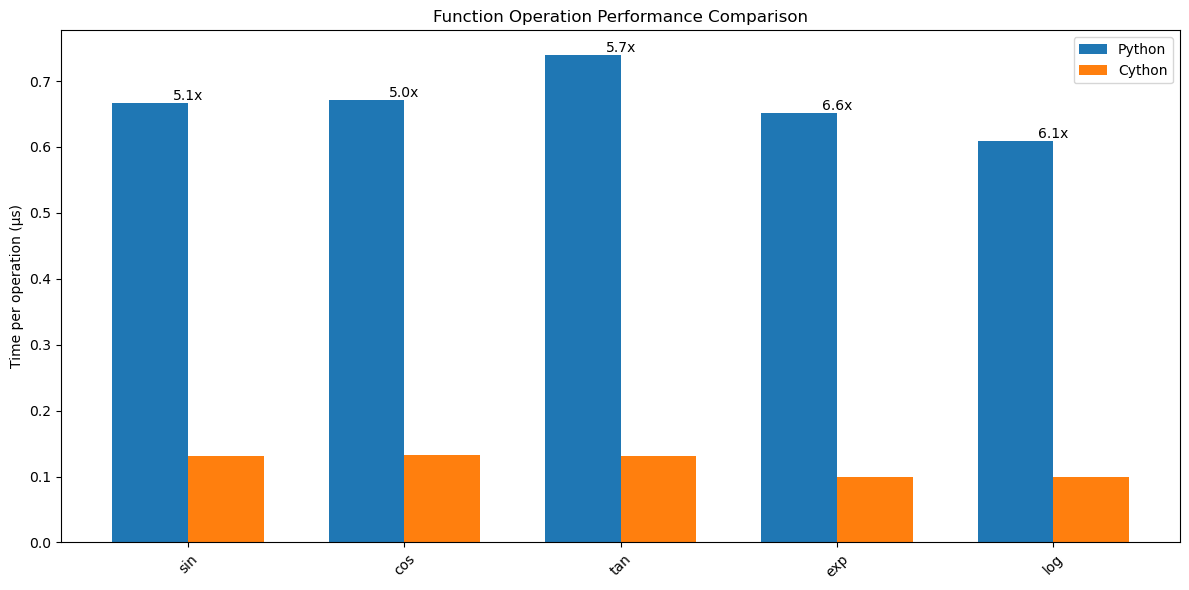

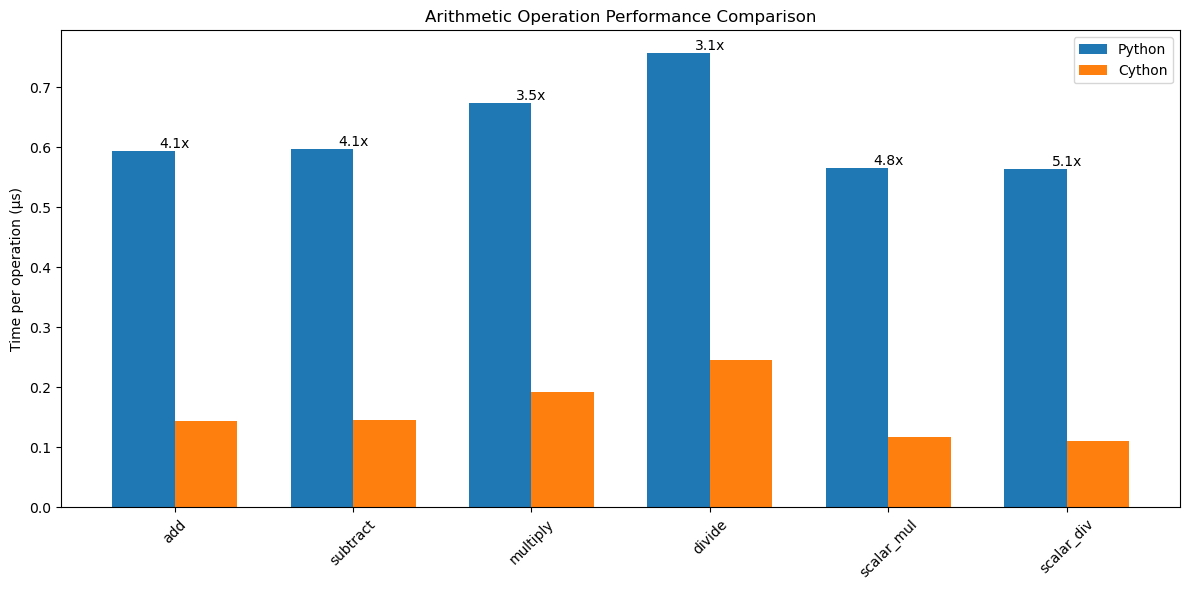

In [69]:
plot_comparison(function_test, 'Function Operation Performance Comparison')
plot_comparison(arithmetic_tests, 'Arithmetic Operation Performance Comparison')